In [1]:
import pandas as pd
import numpy as np

h_nominal = np.array([2.230050448, 1.060394628, 0.963333286, 1.041517012])

datos = {
    'Nodo_1': [2.230050448,
              1.9673, 1.7892, 1.7443, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396,
              1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396],
    'Nodo_2': [1.060394628,
              0.7977, 0.6196, 0.5747, 0.4602, 0.4223, 0.4055, 0.4626, 0.4378, 0.4368,
              0.4482, 0.4442, 0.4205, 0.4070, 0.4094, 0.4115, 0.4253, 0.4236, 0.4200],
    'Nodo_3': [0.963333286,
              0.7006, 0.5225, 0.4776, 0.3668, 0.3423, 0.3310, 0.3598, 0.3147, 0.3130,
              0.3531, 0.3494, 0.3275, 0.3249, 0.3238, 0.3229, 0.2968, 0.3008, 0.3089],
    'Nodo_4': [1.041517012,
              0.7788, 0.6007, 0.5558, 0.4433, 0.4123, 0.3980, 0.4426, 0.4138, 0.4127,
              0.4127, 0.4213, 0.3937, 0.3904, 0.3891, 0.3879, 0.3993, 0.3972, 0.3930],
    'Fuga'  : [0,
               1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(datos)

nodos = ['Nodo_1', 'Nodo_2', 'Nodo_3', 'Nodo_4']
for i, nodo in enumerate(nodos) :
    df[f'Delta {nodo}'] = df[nodo] - h_nominal[i]

focus = [f'Delta {nodo}' for nodo in nodos] + ['Fuga']

c = df.cov()
c

,Nodo_1,Nodo_2,Nodo_3,Nodo_4,Fuga,Delta Nodo_1,Delta Nodo_2,Delta Nodo_3,Delta Nodo_4
Nodo_1,0.023167,0.025274,0.025422,0.025426,-0.029375,0.023167,0.025274,0.025422,0.025426
Nodo_2,0.025274,0.027943,0.028031,0.028089,-0.031170,0.025274,0.027943,0.028031,0.028089
Nodo_3,0.025422,0.028031,0.028366,0.028234,-0.031297,0.025422,0.028031,0.028366,0.028234
Nodo_4,0.025426,0.028089,0.028234,0.028274,-0.031300,0.025426,0.028089,0.028234,0.028274
Fuga,-0.029375,-0.031170,-0.031297,-0.031300,0.052632,-0.029375,-0.031170,-0.031297,-0.031300
Delta Nodo_1,0.023167,0.025274,0.025422,0.025426,-0.029375,0.023167,0.025274,0.025422,0.025426
Delta Nodo_2,0.025274,0.027943,0.028031,0.028089,-0.031170,0.025274,0.027943,0.028031,0.028089
Delta Nodo_3,0.025422,0.028031,0.028366,0.028234,-0.031297,0.025422,0.028031,0.028366,0.028234
Delta Nodo_4,0.025426,0.028089,0.028234,0.028274,-0.031300,0.025426,0.028089,0.028234,0.028274


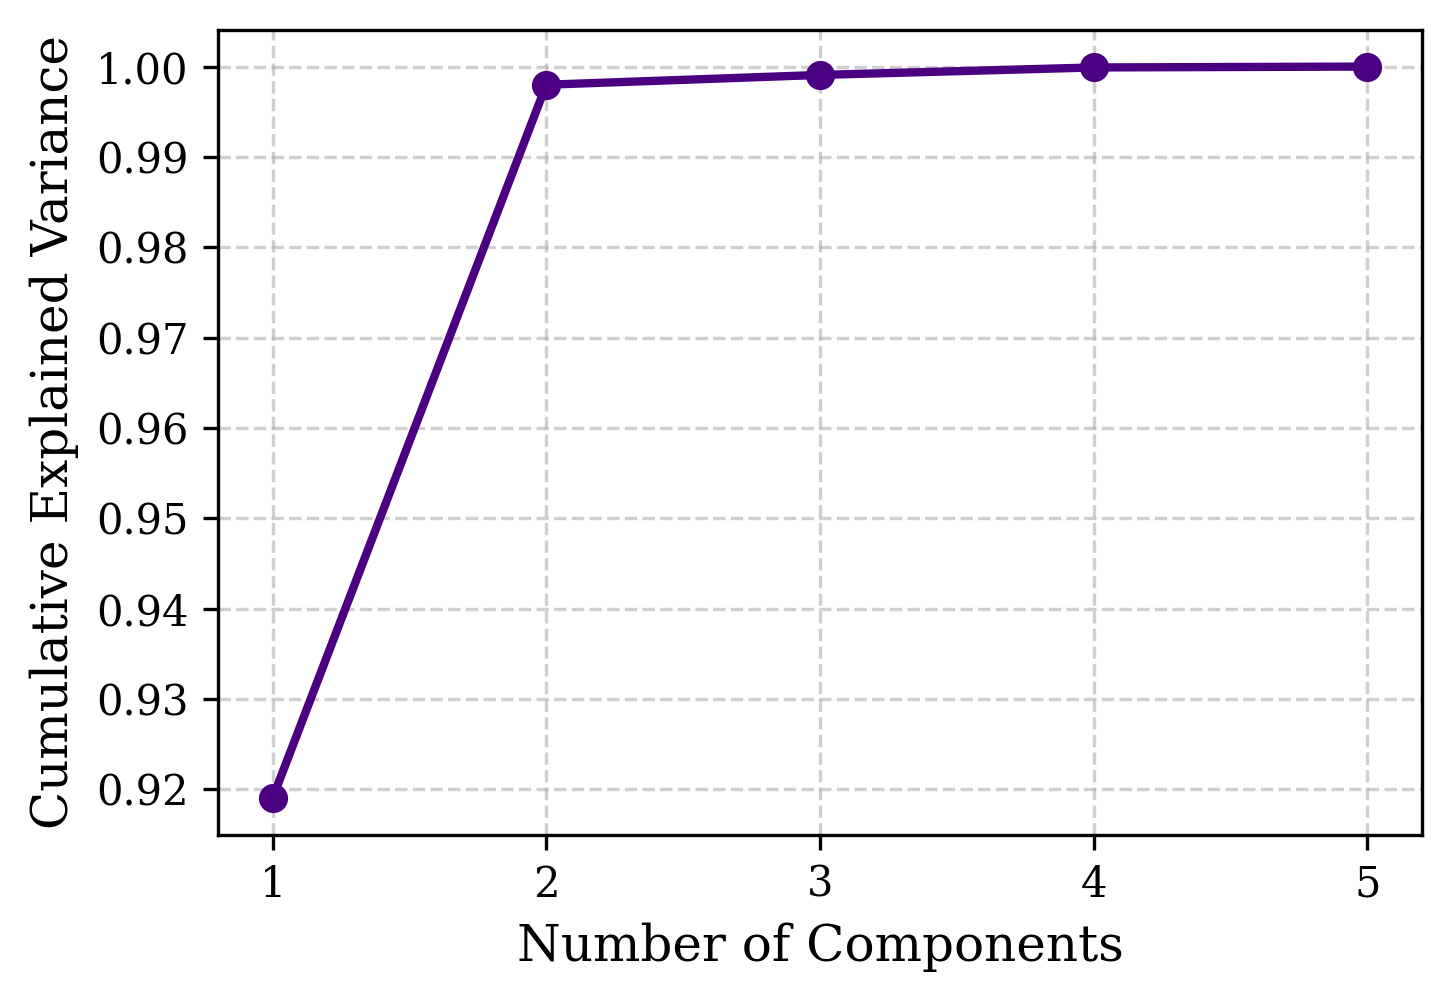

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator # Importa esta librería

covDeltas = df[focus].cov()

eigenvalues, eigenvectors =  np.linalg.eig(covDeltas)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

explained_var = np.cumsum(eigenvalues)/np.sum(eigenvalues)

plt.rcParams.update({
    "font.family": "serif",  # Usa 'serif' para estilo artículo académico
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300       # Alta resolución para el documento
})

plt.figure(figsize = (5,3.5 ))

plt.plot(range(1, len(explained_var) + 1), explained_var,
         color='indigo', marker='o', markersize=6,
         linewidth=2, label='Explained Variance')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.6)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout() # Ajusta automáticamente los márgenes

plt.savefig('pca_variance.png', bbox_inches='tight', transparent=True)


plt.show()

La función de costo que proponemos es
$$E(x)
= -\alpha\sum_i s_i x_i + \gamma\sum_i x_i + \sum_i\sum_j R_{ij} x_i x_j
= \sum_i (\gamma - \alpha s_i)x_i + \sum_i\sum_j R_{ij} x_i x_j
$$
con $s_i = |p_i - p_\text{nom}|$ y $R = \text{cov}(x, x) - \text{diag}(\text{cov}(x, x))$

In [11]:
import numpy as np
import pandas as pd
import itertools

h_nominal = np.array([2.230050448, 1.060394628, 0.963333286, 1.041517012])
datos = {
    'Nodo_1': [2.230050448,
              1.9673, 1.7892, 1.7443, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396,
              1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396],
    'Nodo_2': [1.060394628,
              0.7977, 0.6196, 0.5747, 0.4602, 0.4223, 0.4055, 0.4626, 0.4378, 0.4368,
              0.4482, 0.4442, 0.4205, 0.4070, 0.4094, 0.4115, 0.4253, 0.4236, 0.4200],
    'Nodo_3': [0.963333286,
              0.7006, 0.5225, 0.4776, 0.3668, 0.3423, 0.3310, 0.3598, 0.3147, 0.3130,
              0.3531, 0.3494, 0.3275, 0.3249, 0.3238, 0.3229, 0.2968, 0.3008, 0.3089],
    'Nodo_4': [1.041517012,
              0.7788, 0.6007, 0.5558, 0.4433, 0.4123, 0.3980, 0.4426, 0.4138, 0.4127,
              0.4127, 0.4213, 0.3937, 0.3904, 0.3891, 0.3879, 0.3993, 0.3972, 0.3930]
}
df = pd.DataFrame(datos)
nodos = ['Nodo_1', 'Nodo_2', 'Nodo_3', 'Nodo_4']

for i, nodo in enumerate(nodos):
    df[f'Delta_{nodo}'] = df[nodo] - h_nominal[i]

delta_cols = [f'Delta_{nodo}' for nodo in nodos]

# s_i es la caída promedio de presión en el nodo i avg(|p_i - p|)
s_i = np.abs(df[delta_cols]).mean().values
s_i = s_i/s_i.max() # normalización de sensiblidades

#Matriz de covarianza
cov_matrix = df[delta_cols].cov().values
R = cov_matrix - np.diag(np.diag(cov_matrix))

alpha = 0.5  # Peso/premio por detectar
gamma = 0.4  # Penalización por cada sensor colocado

# --- Algoritmo QUBO ---

Q = R.copy()
np.fill_diagonal(Q, gamma - (alpha * s_i))

lowerCost = 0
bestConfig = None

# Generar todas las combinaciones posibles de [0,1] para 4 sensores
combinaciones = list(itertools.product([0, 1], repeat = 4))

for x_tuple in combinaciones:
    x = np.array(x_tuple)
    costo = x.T @ Q @ x

    if costo < lowerCost:
      lowerCost = costo
      bestConfig = x

print("--- Resultados QUBO ---\n")
print(f"Matriz Q:\n{Q}\n")
print(f"Mejor Configuración: {bestConfig}")
print(f"Costo Mínimo: {lowerCost}")

--- Resultados QUBO ---

Matriz Q:
[[-0.06923792  0.02527438  0.0254219   0.02542622]
 [ 0.02527438 -0.09792134  0.02803121  0.02808852]
 [ 0.0254219   0.02803121 -0.09994829  0.02823353]
 [ 0.02542622  0.02808852  0.02823353 -0.1       ]]

Mejor Configuración: [0 0 1 1]
Costo Mínimo: -0.14348123617125294


In [13]:
!pip install qiskit
!pip install qiskit_optimization
!pip install qiskit_algorithms
!pip install qiskit_aer

!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 27.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 14.5 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=9fa3cefd337945c2dfc04a3ebd0aa4b2862630d5a669466ff3047f9979b2ba2f
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

In [14]:
import numpy as np
import pandas as pd
import itertools

from scipy.optimize import minimize
from qiskit_optimization import QuadraticProgram
from qiskit.circuit.library import qaoa_ansatz
from qiskit_aer.primitives import EstimatorV2, SamplerV2

# ---------------------------------------------------------
# Preparación de datos
# ---------------------------------------------------------
h_nominal = np.array([2.230050448, 1.060394628, 0.963333286, 1.041517012])
datos = {
    'Nodo_1': [2.230050448,
               1.9673, 1.7892, 1.7443, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396,
               1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396, 1.6396],
    'Nodo_2': [1.060394628,
               0.7977, 0.6196, 0.5747, 0.4602, 0.4223, 0.4055, 0.4626, 0.4378, 0.4368,
               0.4482, 0.4442, 0.4205, 0.4070, 0.4094, 0.4115, 0.4253, 0.4236, 0.4200],
    'Nodo_3': [0.963333286,
               0.7006, 0.5225, 0.4776, 0.3668, 0.3423, 0.3310, 0.3598, 0.3147, 0.3130,
               0.3531, 0.3494, 0.3275, 0.3249, 0.3238, 0.3229, 0.2968, 0.3008, 0.3089],
    'Nodo_4': [1.041517012,
               0.7788, 0.6007, 0.5558, 0.4433, 0.4123, 0.3980, 0.4426, 0.4138, 0.4127,
               0.4127, 0.4213, 0.3937, 0.3904, 0.3891, 0.3879, 0.3993, 0.3972, 0.3930]
}
df = pd.DataFrame(datos)
nodos = ['Nodo_1', 'Nodo_2', 'Nodo_3', 'Nodo_4']

for i, nodo in enumerate(nodos):
    df[f'Delta_{nodo}'] = df[nodo] - h_nominal[i]

delta_cols = [f'Delta_{nodo}' for nodo in nodos]

s_i = np.abs(df[delta_cols]).mean().values
s_i = s_i/s_i.max()

cov_matrix = df[delta_cols].cov().values
R = cov_matrix - np.diag(np.diag(cov_matrix))
#R = R / np.abs(R).max()

# ---------------------------------------------------------
# Evaluación de QAOA
# ---------------------------------------------------------
num_qubits = len(delta_cols)

def configEval(alpha, gamma, p = 2):
    # Construir Q para esta iteración
    Q = R.copy()
    np.fill_diagonal(Q, gamma - (alpha * s_i))

    qp_qaoa = QuadraticProgram()
    for i in range(num_qubits):
        qp_qaoa.binary_var(f'x_{i}')

    linear, quadratic = {}, {}
    for i in range(num_qubits):
        linear[i] = Q[i, i]
        for j in range(i + 1, num_qubits):
            quadratic[(i, j)] = Q[i, j] + Q[j, i]

    qp_qaoa.minimize(linear = linear, quadratic = quadratic)

    costOp, offset = qp_qaoa.to_ising()

    ansatz = qaoa_ansatz(costOp, reps = p)

    def qaoa_cost_function(parameters):
        job = EstimatorV2().run([(ansatz, costOp, parameters)])
        resultado = job.result()[0]
        energia = resultado.data.evs

        return energia + offset

    # Optimización clásica
    initial_parameters = np.random.uniform(0, np.pi, 2*p)
    opt_result = minimize(qaoa_cost_function, initial_parameters, method = "BFGS")

    optimal_circuit = ansatz.assign_parameters(opt_result.x)
    optimal_circuit.measure_all()

    sampler_job = SamplerV2().run([optimal_circuit], shots = 8192)
    resultado_sampler = sampler_job.result()[0]

    # Extraer los conteos del registro clásico 'meas'
    conteos = resultado_sampler.data.meas.get_counts()

    total_shots = sum(conteos.values())
    probs = {estado: conteo/total_shots for estado, conteo in conteos.items()}

    top_state = max(probs.items(), key = lambda x: x[1])

    return {
        'Alpha'       : alpha,
        'Gamma'       : gamma,
        'Energia_Min' : opt_result.fun,
        'Mejor_Estado': f"|{top_state[0]}>",
        'Probabilidad': top_state[1]
    }


# ---------------------------------------------------------
# Grid search
# ---------------------------------------------------------
pesosDetection = [0.5, 0.7, 1.0]
pesosSensores  = [0.2, 0.4, 0.6]

resultados_busqueda = []

print("Escaneo de parámetros...\n")

for a, g in itertools.product(pesosDetection, pesosSensores):
    print(f"Evaluando ---> Alpha: {a} | Gamma: {g}")
    resultado = configEval(alpha = a, gamma = g)
    resultados_busqueda.append(resultado)

# ---------------------------------------------------------
# Resultados
# ---------------------------------------------------------
df_resultados = pd.DataFrame(resultados_busqueda)
df_resultados = df_resultados.sort_values(by = 'Energia_Min', ascending = True).reset_index(drop = True)

print("\n--- Ranking de configuraciones ---")
print(df_resultados.to_string(index = False))

Escaneo de parámetros...

Evaluando ---> Alpha: 0.5 | Gamma: 0.2
Evaluando ---> Alpha: 0.5 | Gamma: 0.4
Evaluando ---> Alpha: 0.5 | Gamma: 0.6
Evaluando ---> Alpha: 0.7 | Gamma: 0.2
Evaluando ---> Alpha: 0.7 | Gamma: 0.4
Evaluando ---> Alpha: 0.7 | Gamma: 0.6
Evaluando ---> Alpha: 1.0 | Gamma: 0.2
Evaluando ---> Alpha: 1.0 | Gamma: 0.4
Evaluando ---> Alpha: 1.0 | Gamma: 0.6

--- Ranking de configuraciones ---
 Alpha  Gamma  Energia_Min Mejor_Estado  Probabilidad
   1.0    0.2    -2.811917       |1111>      0.998047
   1.0    0.4    -2.011365       |1111>      0.995361
   0.7    0.2    -1.631911       |1111>      0.996582
   1.0    0.6    -1.211291       |1111>      0.990112
   0.5    0.2    -0.845401       |1111>      0.995361
   0.7    0.4    -0.831446       |1111>      0.984497
   0.5    0.4    -0.130710       |1100>      0.197144
   0.7    0.6    -0.127151       |1110>      0.932495
   0.5    0.6     0.002790       |0000>      0.981934
